# Task 1: Brain Tumor MRI Classification & Clustering

**Module:** CCS3611 Machine Learning – Spring 2026

**Dataset:** BrainTumor.csv – Pre-extracted statistical/textural features from MRI scans

**Objectives:**
1. Build and evaluate 3 classification models (Logistic Regression, Random Forest, XGBoost)
2. Perform K-Means clustering to assess feature-based grouping
3. Identify the most important features via explainability analysis

---

## 0. Install Dependencies
Run this cell first if you are on **Google Colab** or any online Jupyter platform.

In [1]:
# 0. INSTALL DEPENDENCIES (run this cell first on Google Colab / online Jupyter)

!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap statsmodels scipy -q

## 1. Imports & Configuration

In [2]:
# 1. IMPORTS & CONFIGURATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter

%matplotlib inline

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, accuracy_score,
    recall_score, precision_score, silhouette_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.optimize import linear_sum_assignment

import xgboost as xgb
import shap

# Settings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.\n")

All libraries imported successfully.



## 2. Data Loading & Initial Inspection

In [35]:
# 2. DATA LOADING & INITIAL INSPECTION
df = pd.read_csv('BrainTumor.csv')

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn names:\n  {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 5 rows:")
print(df.head().to_string())

# Drop the 'Image' column (row identifier, not a feature)
df = df.drop(columns=['Image'])

# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

print(f"\nFeature matrix shape: {X.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nTarget proportions:\n{y.value_counts(normalize=True).round(3)}")
print(f"\nDescriptive statistics:")
print(X.describe().round(3).to_string())

SECTION 1: DATA LOADING & INITIAL INSPECTION
Dataset shape: 3762 rows x 14 columns

Column names:
  ['Image', 'Class', 'Mean', 'Variance', 'Standard Deviation', 'Entropy', 'Skewness', 'Kurtosis', 'Contrast', 'Energy', 'ASM', 'Homogeneity', 'Dissimilarity', 'Correlation']

Data types:
Image                     str
Class                   int64
Mean                  float64
Variance              float64
Standard Deviation    float64
Entropy               float64
Skewness              float64
Kurtosis              float64
Contrast              float64
Energy                float64
ASM                   float64
Homogeneity           float64
Dissimilarity         float64
Correlation           float64
dtype: object

Missing values:
Image                 0
Class                 0
Mean                  0
Variance              0
Standard Deviation    0
Entropy               0
Skewness              0
Kurtosis              0
Contrast              0
Energy                0
ASM                   0


## 3. Exploratory Data Analysis (EDA)

- Class distribution
- Feature distributions by class (box plots)
- Correlation heatmap & redundant feature identification
- VIF multicollinearity analysis


SECTION 2: EXPLORATORY DATA ANALYSIS


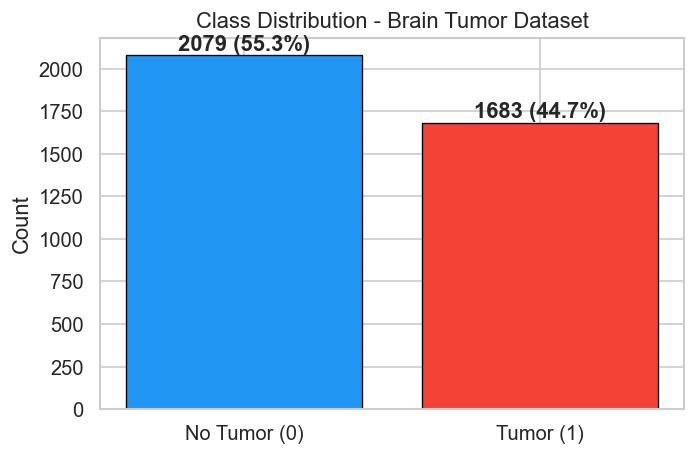

Class balance ratio: 0.810


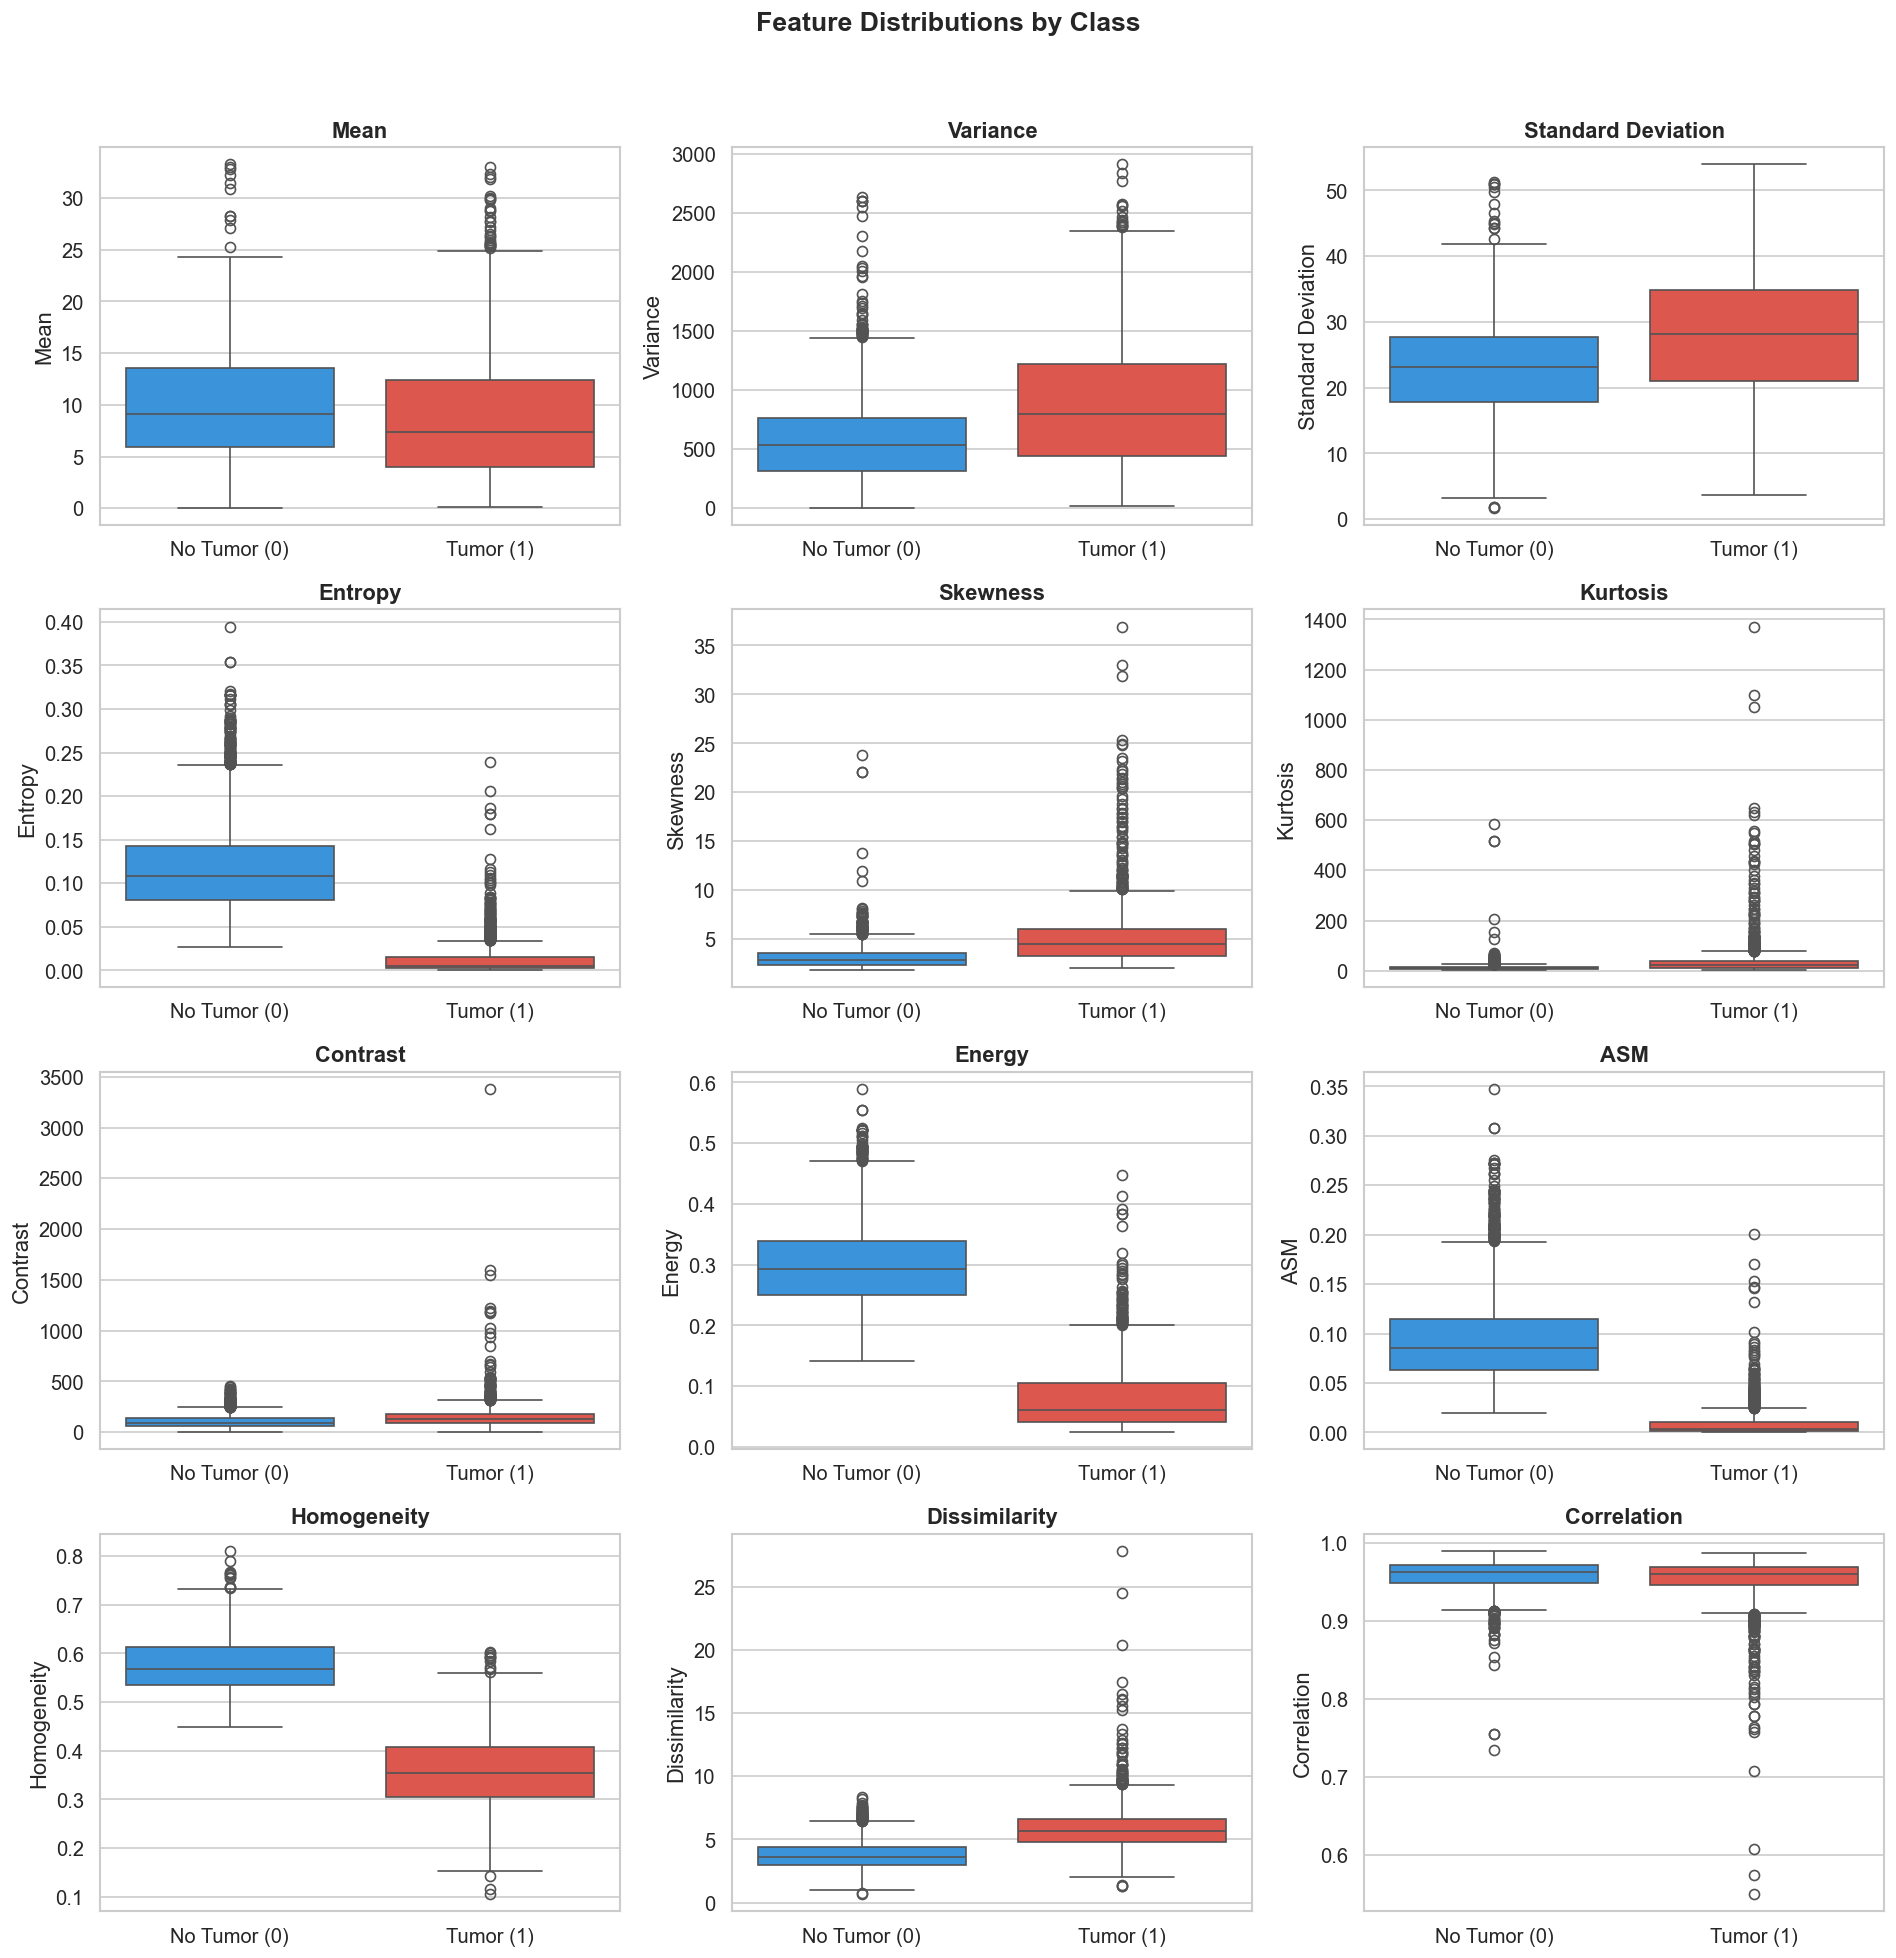

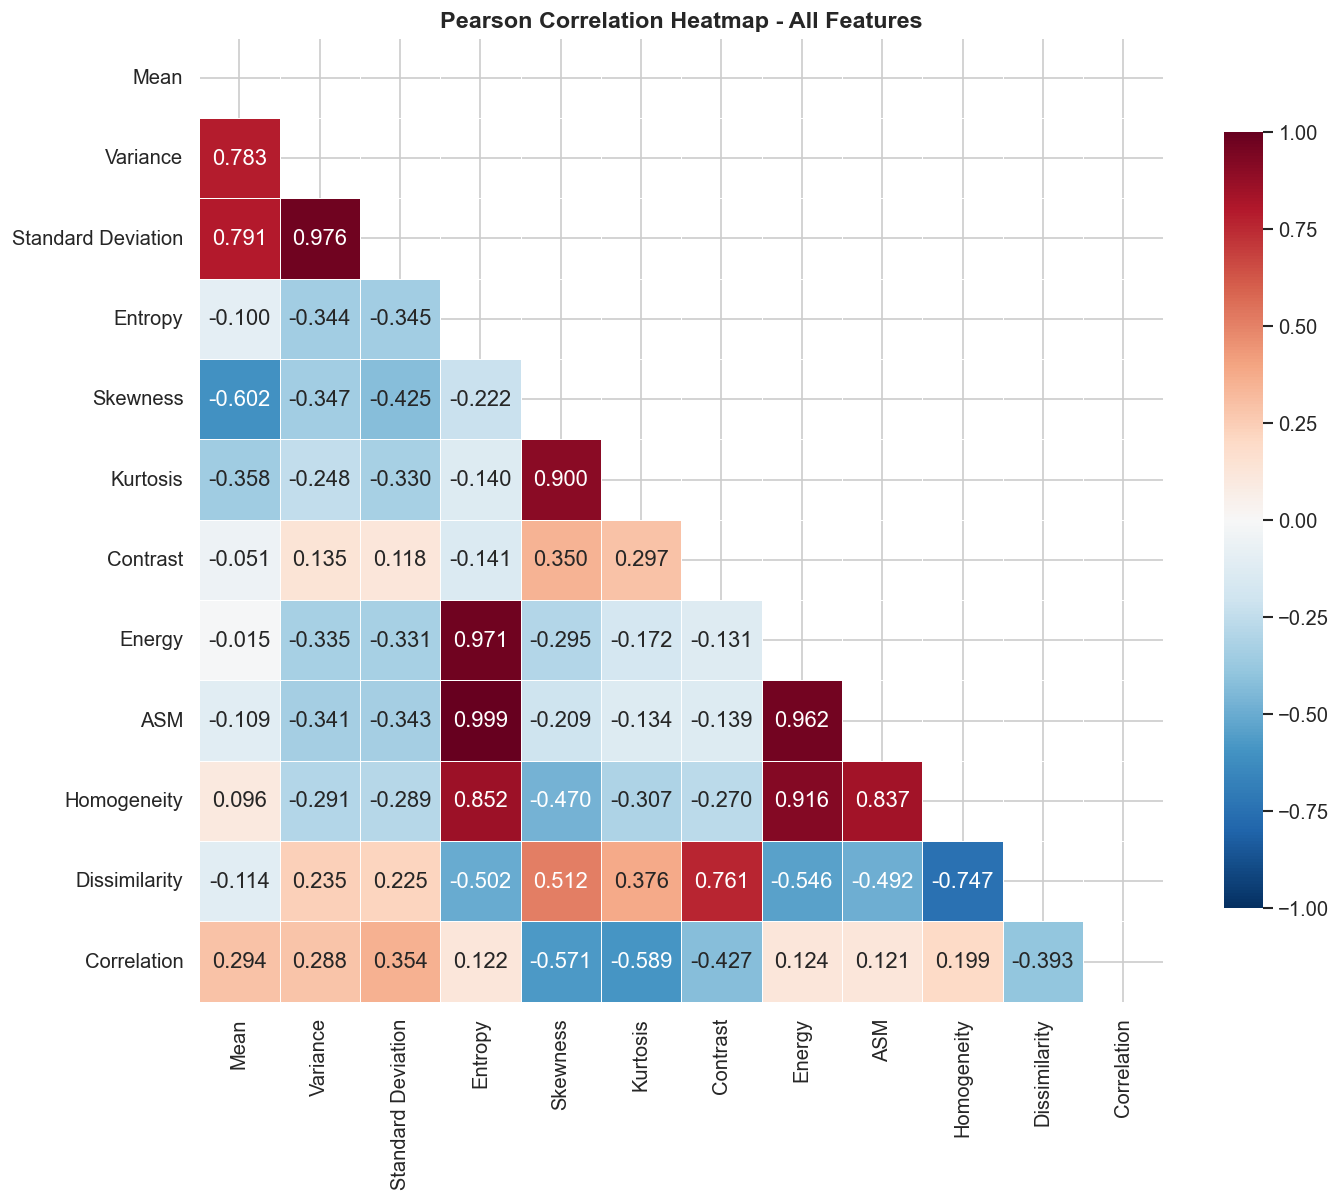


=== Highly Correlated Feature Pairs (|r| > 0.9) ===
  Variance <-> Standard Deviation: r = 0.9757
  Entropy <-> Energy: r = 0.9713
  Entropy <-> ASM: r = 0.9992
  Energy <-> ASM: r = 0.9616
  Energy <-> Homogeneity: r = 0.9160


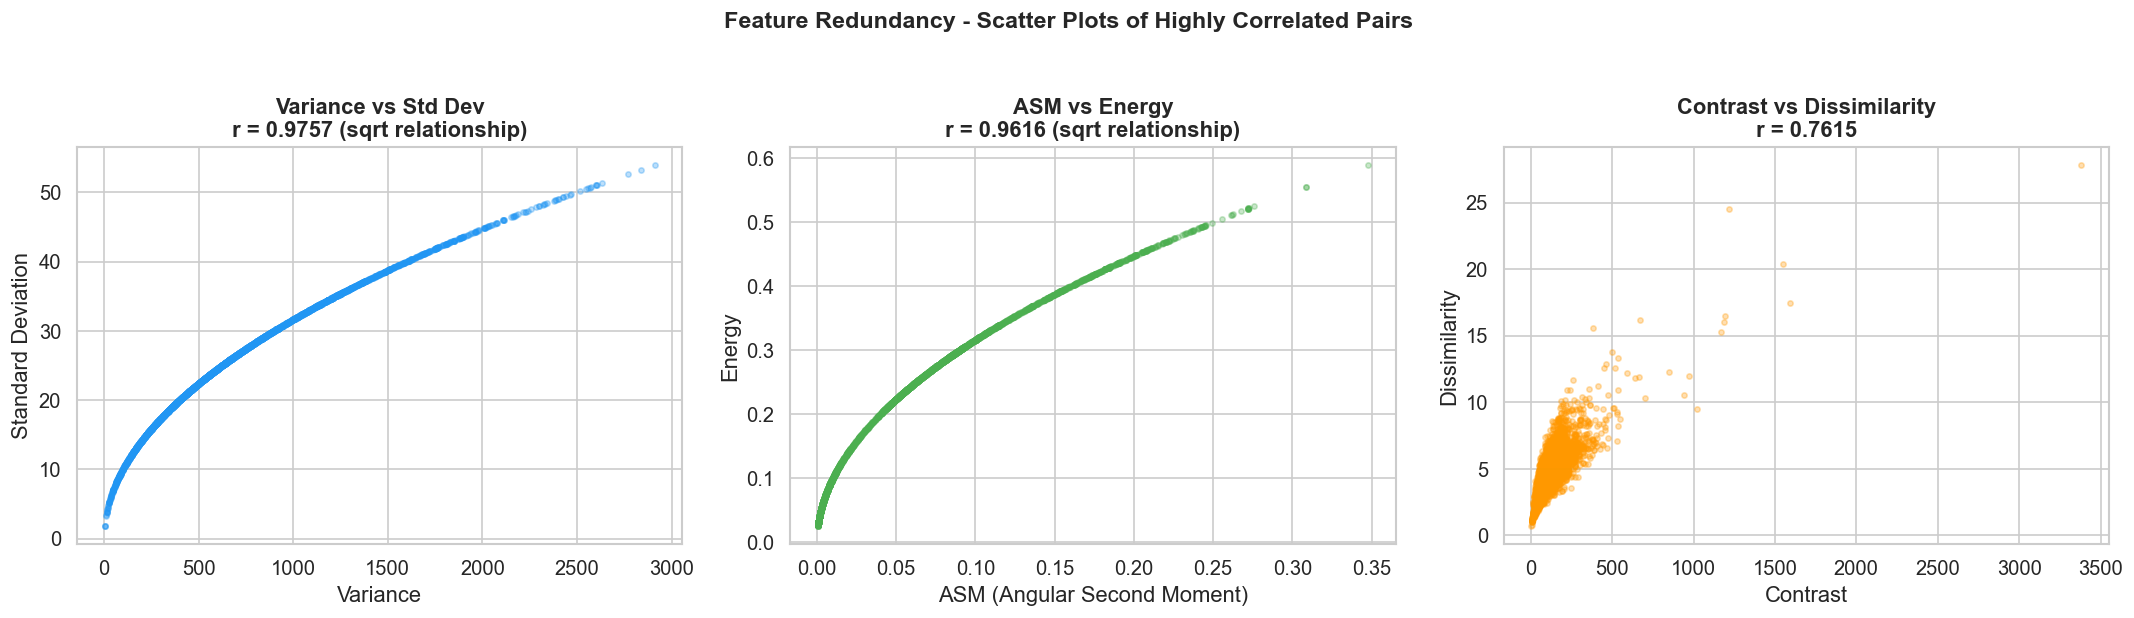


=== Mathematical Verification ===
StdDev = sqrt(Variance)? Max error: 0.000000
Energy = sqrt(ASM)?      Max error: 0.000000

=== Variance Inflation Factors (BEFORE feature removal) ===
           Feature         VIF       Status
           Entropy 8785.904279 SEVERE (>10)
               ASM 6562.723894 SEVERE (>10)
            Energy  217.580064 SEVERE (>10)
Standard Deviation   39.248475 SEVERE (>10)
          Variance   32.112502 SEVERE (>10)
       Homogeneity   31.759466 SEVERE (>10)
          Skewness   25.691455 SEVERE (>10)
     Dissimilarity   14.550585 SEVERE (>10)
          Kurtosis   12.610481 SEVERE (>10)
              Mean    7.722629    HIGH (>5)
          Contrast    5.993651    HIGH (>5)
       Correlation    2.186154           OK


In [4]:
# 3. EXPLORATORY DATA ANALYSIS (EDA)

# --- 3.1 Class Distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
class_counts = y.value_counts()
bars = ax.bar(['No Tumor (0)', 'Tumor (1)'], class_counts.values,
              color=['#2196F3', '#F44336'], edgecolor='black', linewidth=0.8)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count} ({count/len(y)*100:.1f}%)', ha='center', fontweight='bold')

ax.set_ylabel('Count')
ax.set_title('Class Distribution - Brain Tumor Dataset')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print(f"Class balance ratio: {class_counts.min() / class_counts.max():.3f}")

# --- 3.2 Box Plots: Feature Distributions by Class ---
features = X.columns.tolist()
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=df, x='Class', y=feat, ax=axes[i],
                palette={0: '#2196F3', 1: '#F44336'}, hue='Class', legend=False)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['No Tumor (0)', 'Tumor (1)'])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('box_plots_by_class.png', bbox_inches='tight')
plt.show()

# --- 3.3 Correlation Heatmap ---
corr_matrix = X.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation Heatmap - All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Identify highly correlated pairs (|r| > 0.9)
print('\n=== Highly Correlated Feature Pairs (|r| > 0.9) ===')
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            pair = (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            high_corr_pairs.append(pair)
            print(f'  {pair[0]} <-> {pair[1]}: r = {pair[2]:.4f}')

if not high_corr_pairs:
    print('  None found.')

# --- 3.4 Scatter Plots of Redundant Pairs ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pair 1: Variance vs Standard Deviation
axes[0].scatter(X['Variance'], X['Standard Deviation'], alpha=0.3, s=10, c='#2196F3')
axes[0].set_xlabel('Variance')
axes[0].set_ylabel('Standard Deviation')
r1 = X['Variance'].corr(X['Standard Deviation'])
axes[0].set_title(f'Variance vs Std Dev\nr = {r1:.4f} (sqrt relationship)', fontweight='bold')

# Pair 2: Energy vs ASM
axes[1].scatter(X['ASM'], X['Energy'], alpha=0.3, s=10, c='#4CAF50')
axes[1].set_xlabel('ASM (Angular Second Moment)')
axes[1].set_ylabel('Energy')
r2 = X['ASM'].corr(X['Energy'])
axes[1].set_title(f'ASM vs Energy\nr = {r2:.4f} (sqrt relationship)', fontweight='bold')

# Pair 3: Contrast vs Dissimilarity
axes[2].scatter(X['Contrast'], X['Dissimilarity'], alpha=0.3, s=10, c='#FF9800')
axes[2].set_xlabel('Contrast')
axes[2].set_ylabel('Dissimilarity')
r3 = X['Contrast'].corr(X['Dissimilarity'])
axes[2].set_title(f'Contrast vs Dissimilarity\nr = {r3:.4f}', fontweight='bold')

plt.suptitle('Feature Redundancy - Scatter Plots of Highly Correlated Pairs',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('redundant_pairs_scatter.png', bbox_inches='tight')
plt.show()

# Mathematical verification
print('\n=== Mathematical Verification ===')
print(f'StdDev = sqrt(Variance)? Max error: {(X["Standard Deviation"] - np.sqrt(X["Variance"])).abs().max():.6f}')
print(f'Energy = sqrt(ASM)?      Max error: {(X["Energy"] - np.sqrt(X["ASM"])).abs().max():.6f}')

# --- 3.5 Variance Inflation Factor (VIF) ---
X_scaled_temp = StandardScaler().fit_transform(X)
vif_data = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X_scaled_temp, i) for i in range(X_scaled_temp.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_data['Status'] = vif_data['VIF'].apply(
    lambda x: 'SEVERE (>10)' if x > 10 else ('HIGH (>5)' if x > 5 else 'OK'))

print('\n=== Variance Inflation Factors (BEFORE feature removal) ===')
print(vif_data.to_string(index=False))

## 4. Feature Selection & Preprocessing

Drop mathematically redundant features (Variance = StdDev², ASM = Energy²) and perform stratified 80/20 train/test split.


SECTION 3: FEATURE SELECTION & PREPROCESSING
Keeping Dissimilarity (r = 0.7615 with Contrast <= 0.9 threshold)

Dropped: ['Variance', 'ASM']
Remaining features (10): ['Mean', 'Standard Deviation', 'Entropy', 'Skewness', 'Kurtosis', 'Contrast', 'Energy', 'Homogeneity', 'Dissimilarity', 'Correlation']

=== VIF AFTER Feature Removal ===
           Feature       VIF       Status
            Energy 50.187590 SEVERE (>10)
       Homogeneity 28.987576 SEVERE (>10)
           Entropy 28.186569 SEVERE (>10)
          Skewness 20.412760 SEVERE (>10)
     Dissimilarity 14.143490 SEVERE (>10)
          Kurtosis 11.491357 SEVERE (>10)
              Mean  6.682949    HIGH (>5)
Standard Deviation  6.662762    HIGH (>5)
          Contrast  5.765698    HIGH (>5)
       Correlation  2.144133           OK


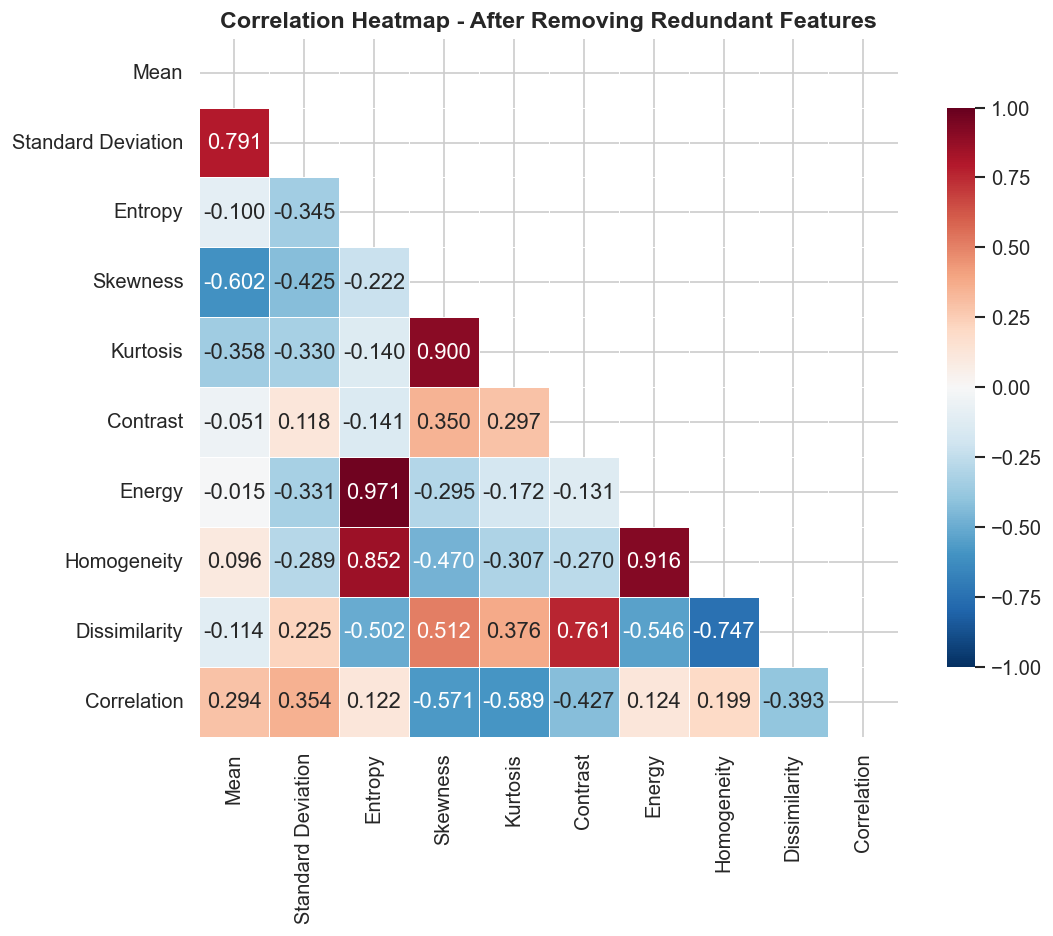


Training set: 3009 samples
Test set:     753 samples

Training class distribution:
Class
0    1663
1    1346
Name: count, dtype: int64

Test class distribution:
Class
0    416
1    337
Name: count, dtype: int64


In [5]:
# 4. FEATURE SELECTION & PREPROCESSING

features_to_drop = ['Variance', 'ASM']

# Conditionally drop Dissimilarity
contrast_dissimilarity_corr = X['Contrast'].corr(X['Dissimilarity'])
if abs(contrast_dissimilarity_corr) > 0.9:
    features_to_drop.append('Dissimilarity')
    print(f'Dropping Dissimilarity (r = {contrast_dissimilarity_corr:.4f} with Contrast > 0.9 threshold)')
else:
    print(f'Keeping Dissimilarity (r = {contrast_dissimilarity_corr:.4f} with Contrast <= 0.9 threshold)')

X_clean = X.drop(columns=features_to_drop)
print(f'\nDropped: {features_to_drop}')
print(f'Remaining features ({X_clean.shape[1]}): {list(X_clean.columns)}')

# Recompute VIF after removal
X_scaled_temp2 = StandardScaler().fit_transform(X_clean)
vif_data2 = pd.DataFrame({
    'Feature': X_clean.columns,
    'VIF': [variance_inflation_factor(X_scaled_temp2, i) for i in range(X_scaled_temp2.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
vif_data2['Status'] = vif_data2['VIF'].apply(
    lambda x: 'SEVERE (>10)' if x > 10 else ('HIGH (>5)' if x > 5 else 'OK'))

print('\n=== VIF AFTER Feature Removal ===')
print(vif_data2.to_string(index=False))

# Cleaned correlation heatmap
corr_clean = X_clean.corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_clean, dtype=bool))
sns.heatmap(corr_clean, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap - After Removing Redundant Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap_cleaned.png', bbox_inches='tight')
plt.show()

# Train/Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nTraining class distribution:\n{y_train.value_counts()}')
print(f'\nTest class distribution:\n{y_test.value_counts()}')

## 5. Classification — Three Models

All models use `Pipeline(StandardScaler + Classifier)` with `GridSearchCV` (5-fold stratified CV, F1 scoring).

| Model | Type | Why |
|---|---|---|
| Logistic Regression | Linear | Interpretable baseline, coefficients = feature importance |
| Random Forest | Bagging ensemble | Robust to correlated features, built-in importance |
| XGBoost | Boosting ensemble | Compares bagging vs boosting, SHAP-compatible |

In [6]:
# 5. CLASSIFICATION - THREE MODELS
# ==========================================================================

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
feature_names = X_clean.columns.tolist()

# --- Model 1: Logistic Regression ---
# Linear baseline. Coefficients directly indicate feature importance.
# L1 penalty can zero-out redundant features.
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['saga'],
    'clf__class_weight': [None, 'balanced']
}

# --- Model 2: Random Forest ---
# Bagging ensemble, robust to correlated features.
# Provides built-in feature importance.
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE))
])
param_grid_rf = {
    'clf__n_estimators': [100, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': [None, 'balanced']
}

# --- Model 3: XGBoost ---
# Boosting ensemble. Comparing bagging (RF) vs boosting (XGB) demonstrates
# understanding of different ensemble strategies.
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', xgb.XGBClassifier(
        random_state=RANDOM_STATE, eval_metric='logloss'
    ))
])

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

param_grid_xgb = {
    'clf__n_estimators': [100, 300],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.1, 0.3],
    'clf__subsample': [0.8, 1.0],
    'clf__scale_pos_weight': [1, scale_pos]
}

models = {
    'Logistic Regression': (pipe_lr, param_grid_lr),
    'Random Forest': (pipe_rf, param_grid_rf),
    'XGBoost': (pipe_xgb, param_grid_xgb)
}

print('Models and hyperparameter grids defined:')
for name, (pipe, grid) in models.items():
    total_combos = 1
    for vals in grid.values():
        total_combos *= len(vals)
    print(f'  {name}: {total_combos} hyperparameter combinations')

# --- Train all models ---
best_models = {}
cv_results_summary = []

for name, (pipeline, param_grid) in models.items():
    print(f'\n{"="*60}')
    print(f'Training: {name}')
    print(f'{"="*60}')

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv_strategy,
        scoring='f1',
        n_jobs=1,
        verbose=0,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search

    print(f'Best CV F1 Score:  {grid_search.best_score_:.4f}')
    print(f'Best Parameters:')
    for param, value in grid_search.best_params_.items():
        print(f'  {param}: {value}')

    cv_results_summary.append({
        'Model': name,
        'Best CV F1': grid_search.best_score_,
        'Train F1 (mean)': grid_search.cv_results_['mean_train_score'][grid_search.best_index_],
    })

print('\n\n=== Cross-Validation Summary ===')
print(pd.DataFrame(cv_results_summary).round(4).to_string(index=False))


SECTION 4: CLASSIFICATION (3 MODELS)
Models and hyperparameter grids defined:
  Logistic Regression: 20 hyperparameter combinations
  Random Forest: 48 hyperparameter combinations
  XGBoost: 72 hyperparameter combinations

Training: Logistic Regression
Best CV F1 Score:  0.9790
Best Parameters:
  clf__C: 1
  clf__class_weight: balanced
  clf__penalty: l2
  clf__solver: saga

Training: Random Forest
Best CV F1 Score:  0.9850
Best Parameters:
  clf__class_weight: balanced
  clf__max_depth: None
  clf__max_features: sqrt
  clf__min_samples_split: 2
  clf__n_estimators: 100

Training: XGBoost
Best CV F1 Score:  0.9896
Best Parameters:
  clf__learning_rate: 0.1
  clf__max_depth: 5
  clf__n_estimators: 300
  clf__scale_pos_weight: 1
  clf__subsample: 0.8


=== Cross-Validation Summary ===
              Model  Best CV F1  Train F1 (mean)
Logistic Regression      0.9790           0.9798
      Random Forest      0.9850           1.0000
            XGBoost      0.9896           1.0000


## 6. Test Set Evaluation

Confusion matrices, ROC curves, and metric comparison (Accuracy, Precision, Recall, F1, AUC-ROC).


SECTION 5: TEST SET EVALUATION


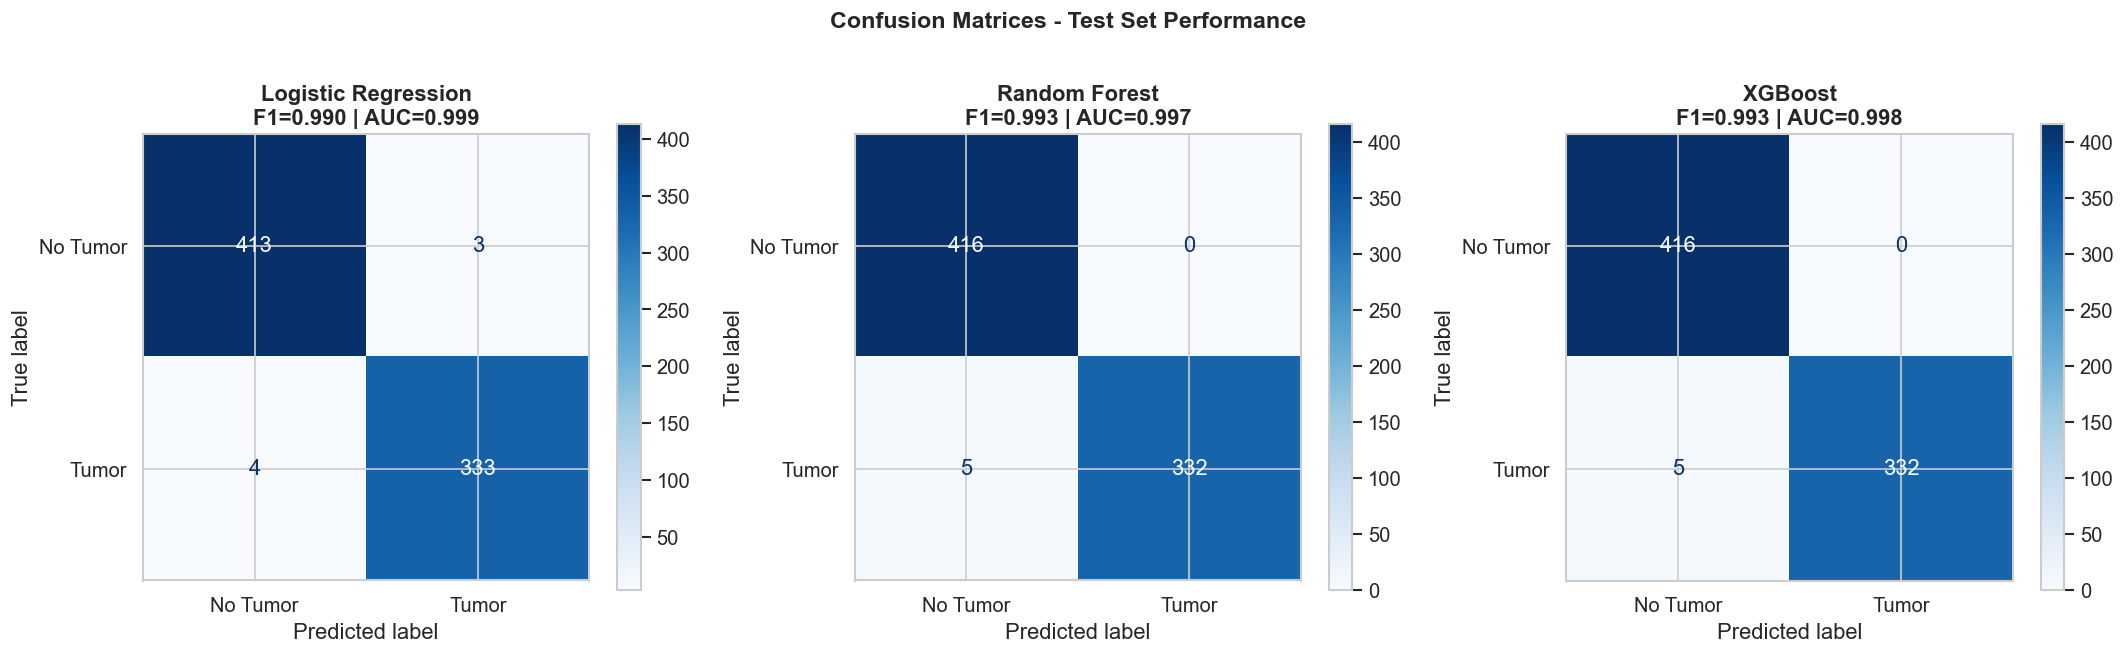


=== Test Set Performance Summary ===
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.9907     0.9911  0.9881    0.9896   0.9993
Random Forest          0.9934     1.0000  0.9852    0.9925   0.9971
XGBoost                0.9934     1.0000  0.9852    0.9925   0.9981


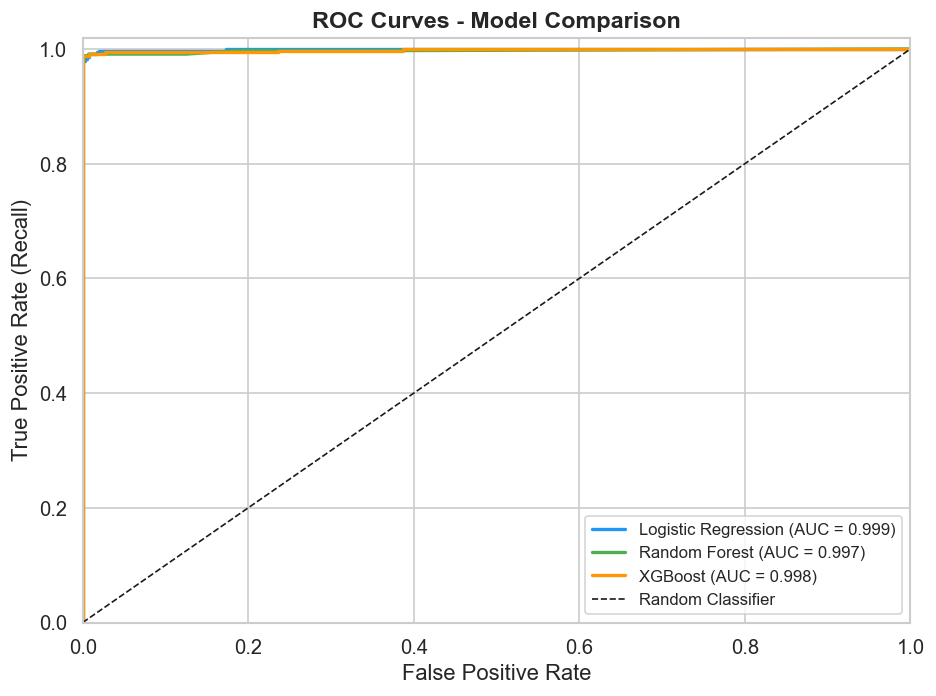


Logistic Regression - Detailed Classification Report
              precision    recall  f1-score   support

    No Tumor       0.99      0.99      0.99       416
       Tumor       0.99      0.99      0.99       337

    accuracy                           0.99       753
   macro avg       0.99      0.99      0.99       753
weighted avg       0.99      0.99      0.99       753


Random Forest - Detailed Classification Report
              precision    recall  f1-score   support

    No Tumor       0.99      1.00      0.99       416
       Tumor       1.00      0.99      0.99       337

    accuracy                           0.99       753
   macro avg       0.99      0.99      0.99       753
weighted avg       0.99      0.99      0.99       753


XGBoost - Detailed Classification Report
              precision    recall  f1-score   support

    No Tumor       0.99      1.00      0.99       416
       Tumor       1.00      0.99      0.99       337

    accuracy                          

In [7]:
# 6. TEST SET EVALUATION

test_results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, grid_search) in enumerate(best_models.items()):
    y_pred = grid_search.predict(X_test)
    y_proba = grid_search.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    test_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Tumor', 'Tumor']).plot(ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name}\nF1={f1:.3f} | AUC={auc:.3f}', fontweight='bold')

plt.suptitle('Confusion Matrices - Test Set Performance', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

results_df = pd.DataFrame(test_results).set_index('Model')
print('\n=== Test Set Performance Summary ===')
print(results_df.round(4).to_string())

# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for (name, grid_search), color in zip(best_models.items(), colors):
    y_proba = grid_search.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

# Detailed classification reports
for name, grid_search in best_models.items():
    y_pred = grid_search.predict(X_test)
    print(f'\n{"="*50}')
    print(f'{name} - Detailed Classification Report')
    print(f'{"="*50}')
    print(classification_report(y_test, y_pred, target_names=['No Tumor', 'Tumor']))

## 7. Feature Explainability

- **Logistic Regression:** Coefficient magnitudes
- **Random Forest:** Permutation importance
- **XGBoost:** SHAP values (beeswarm + bar plots)
- **Consensus:** Vote across all 3 models for top-2 features


SECTION 6: FEATURE EXPLAINABILITY


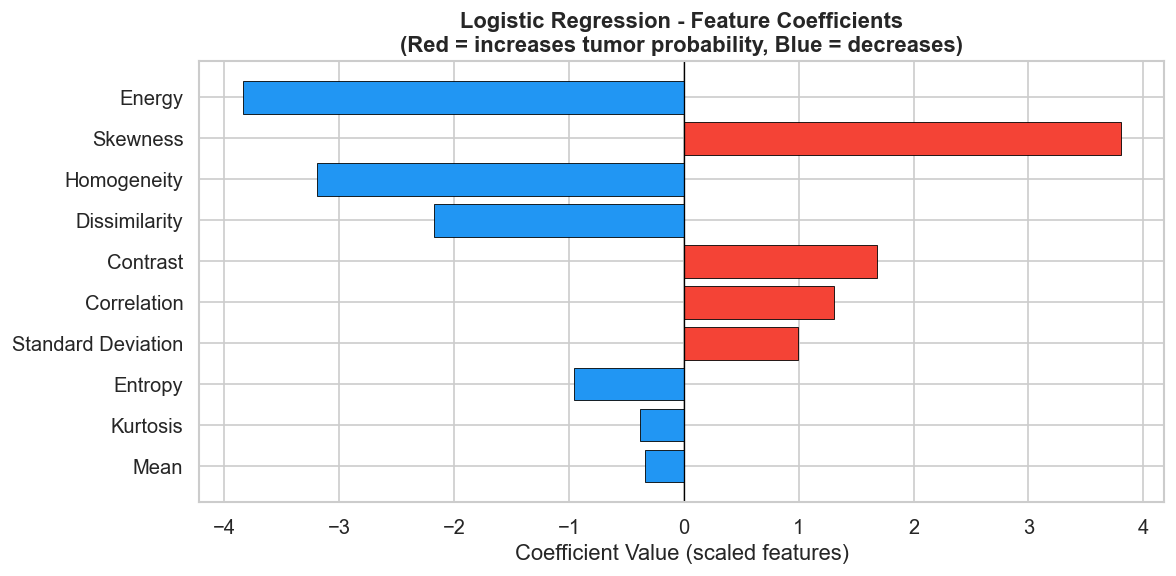


Logistic Regression Feature Importance (by |coefficient|):
           Feature  Coefficient  Abs_Coefficient
            Energy    -3.836733         3.836733
          Skewness     3.802960         3.802960
       Homogeneity    -3.192609         3.192609
     Dissimilarity    -2.173454         2.173454
          Contrast     1.682465         1.682465
       Correlation     1.310702         1.310702
Standard Deviation     0.995167         0.995167
           Entropy    -0.957662         0.957662
          Kurtosis    -0.384399         0.384399
              Mean    -0.341780         0.341780


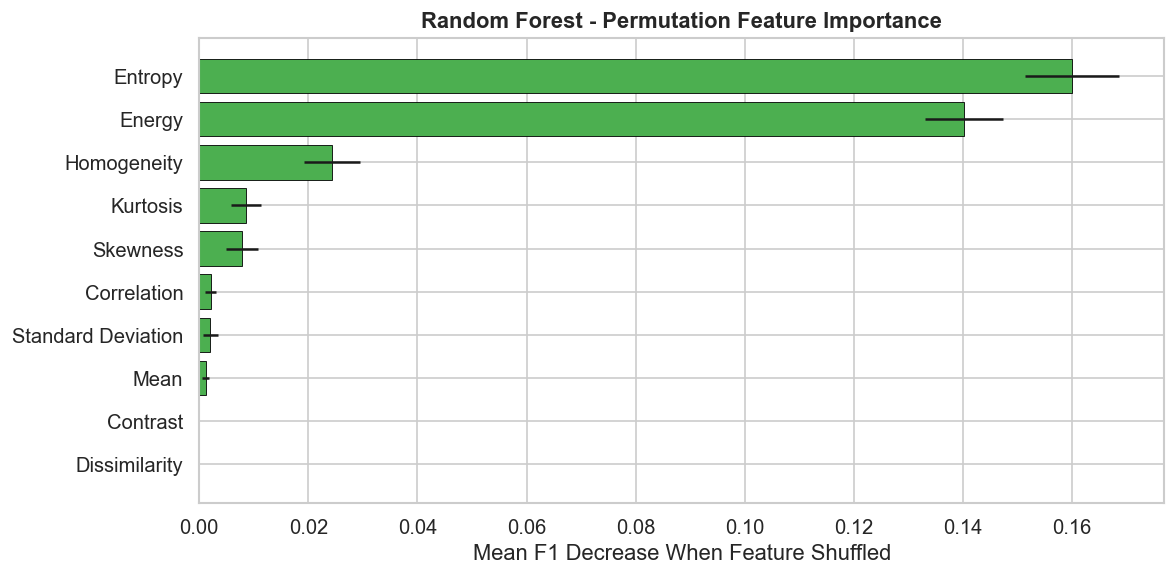


Random Forest Permutation Importance:
           Feature  Importance_Mean  Importance_Std
           Entropy         0.159893        0.008616
            Energy         0.140160        0.007212
       Homogeneity         0.024338        0.005111
          Kurtosis         0.008515        0.002729
          Skewness         0.007831        0.002973
       Correlation         0.002114        0.001002
Standard Deviation         0.002062        0.001321
              Mean         0.001207        0.000603
          Contrast         0.000000        0.000000
     Dissimilarity         0.000000        0.000000


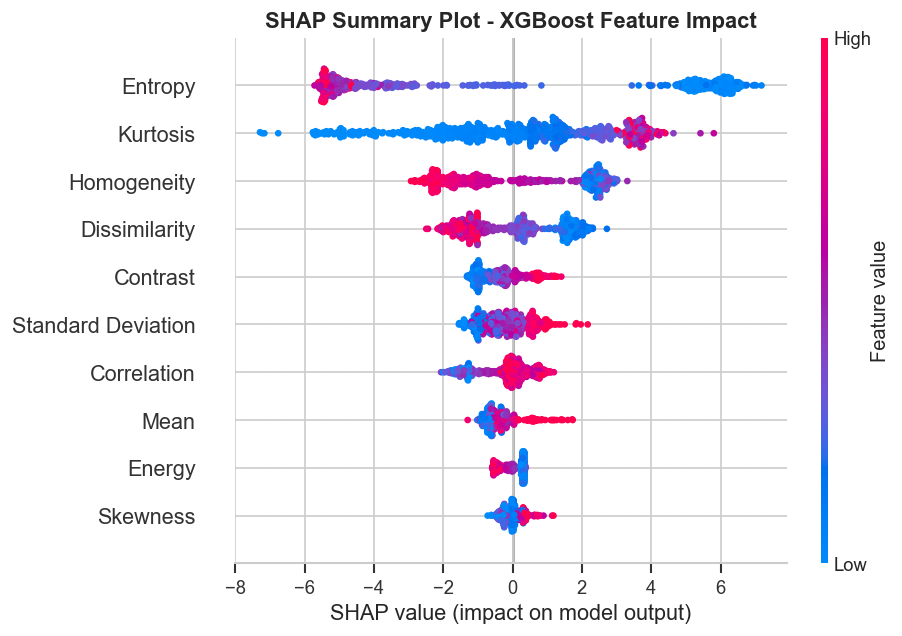

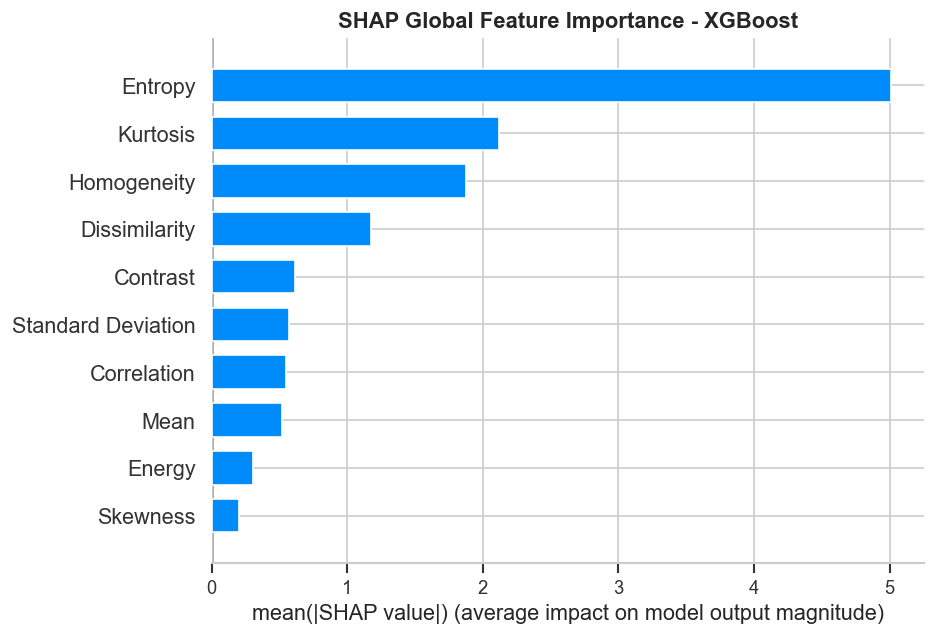


TOP 2 MOST IMPORTANT FEATURES - Consensus Across Models

Logistic Regression (by |coefficient|): ['Energy', 'Skewness']
Random Forest (by permutation importance): ['Entropy', 'Energy']
XGBoost (by mean |SHAP|): ['Entropy', 'Kurtosis']

>>> CONSENSUS TOP 2: ['Energy', 'Entropy']
    (Voted by 2/3 and 2/3 models respectively)


In [8]:
# 7. FEATURE EXPLAINABILITY

# --- 7.1 Logistic Regression Coefficients ---
lr_model = best_models['Logistic Regression'].best_estimator_
lr_coefs = lr_model.named_steps['clf'].coef_[0]

lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_coefs,
    'Abs_Coefficient': np.abs(lr_coefs)
}).sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#F44336' if c > 0 else '#2196F3' for c in lr_importance['Coefficient']]
ax.barh(lr_importance['Feature'], lr_importance['Coefficient'], color=bar_colors,
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Coefficient Value (scaled features)')
ax.set_title('Logistic Regression - Feature Coefficients\n'
             '(Red = increases tumor probability, Blue = decreases)',
             fontweight='bold')
ax.invert_yaxis()
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()

print('\nLogistic Regression Feature Importance (by |coefficient|):')
print(lr_importance[['Feature', 'Coefficient', 'Abs_Coefficient']].to_string(index=False))

# --- 7.2 Random Forest Permutation Importance ---
rf_model = best_models['Random Forest'].best_estimator_
X_test_scaled = rf_model.named_steps['scaler'].transform(X_test)

perm_imp = permutation_importance(
    rf_model.named_steps['clf'], X_test_scaled, y_test,
    n_repeats=30, random_state=RANDOM_STATE, scoring='f1'
)

perm_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_imp.importances_mean,
    'Importance_Std': perm_imp.importances_std
}).sort_values('Importance_Mean', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(perm_imp_df['Feature'], perm_imp_df['Importance_Mean'],
        xerr=perm_imp_df['Importance_Std'], color='#4CAF50', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mean F1 Decrease When Feature Shuffled')
ax.set_title('Random Forest - Permutation Feature Importance', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('rf_permutation_importance.png', bbox_inches='tight')
plt.show()

print('\nRandom Forest Permutation Importance:')
print(perm_imp_df.to_string(index=False))

# --- 7.3 SHAP Values (XGBoost) ---
xgb_model = best_models['XGBoost'].best_estimator_
X_test_scaled_xgb = xgb_model.named_steps['scaler'].transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled_xgb, columns=feature_names)

explainer = shap.TreeExplainer(xgb_model.named_steps['clf'])
shap_values = explainer.shap_values(X_test_scaled_df)

# SHAP Summary (beeswarm)
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.title('SHAP Summary Plot - XGBoost Feature Impact', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

# SHAP Bar Plot
fig, ax = plt.subplots(figsize=(10, 5))
shap.summary_plot(shap_values, X_test_scaled_df, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance - XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

# --- 7.4 Consensus Top 2 Features ---

lr_top2 = lr_importance['Feature'].head(2).tolist()
print(f'\nLogistic Regression (by |coefficient|): {lr_top2}')

rf_top2 = perm_imp_df['Feature'].head(2).tolist()
print(f'Random Forest (by permutation importance): {rf_top2}')

shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_|SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_|SHAP|', ascending=False)
xgb_top2 = shap_importance['Feature'].head(2).tolist()
print(f'XGBoost (by mean |SHAP|): {xgb_top2}')

all_top2 = lr_top2 + rf_top2 + xgb_top2
feature_votes = Counter(all_top2)
consensus_top2 = [f for f, _ in feature_votes.most_common(2)]
print(f'\n>>> CONSENSUS TOP 2: {consensus_top2}')
print(f'    (Voted by {len([m for m in [lr_top2, rf_top2, xgb_top2] if consensus_top2[0] in m])}/3 and '
      f'{len([m for m in [lr_top2, rf_top2, xgb_top2] if consensus_top2[1] in m])}/3 models respectively)')

## 8. Clustering Analysis

- Elbow method + silhouette scores for optimal k
- K-Means (k=2) to match binary classification
- External validation: ARI, NMI, Purity
- PCA visualisation (actual labels vs clusters)
- Hungarian algorithm for optimal label alignment


Evaluating k values:
  k=2: Inertia=26806.8, Silhouette=0.3429
  k=3: Inertia=21244.8, Silhouette=0.3469
  k=4: Inertia=17391.2, Silhouette=0.2918
  k=5: Inertia=15446.1, Silhouette=0.2544
  k=6: Inertia=14086.1, Silhouette=0.2646
  k=7: Inertia=12885.4, Silhouette=0.2632
  k=8: Inertia=11640.3, Silhouette=0.2600
  k=9: Inertia=10712.5, Silhouette=0.2673
  k=10: Inertia=10007.7, Silhouette=0.2552


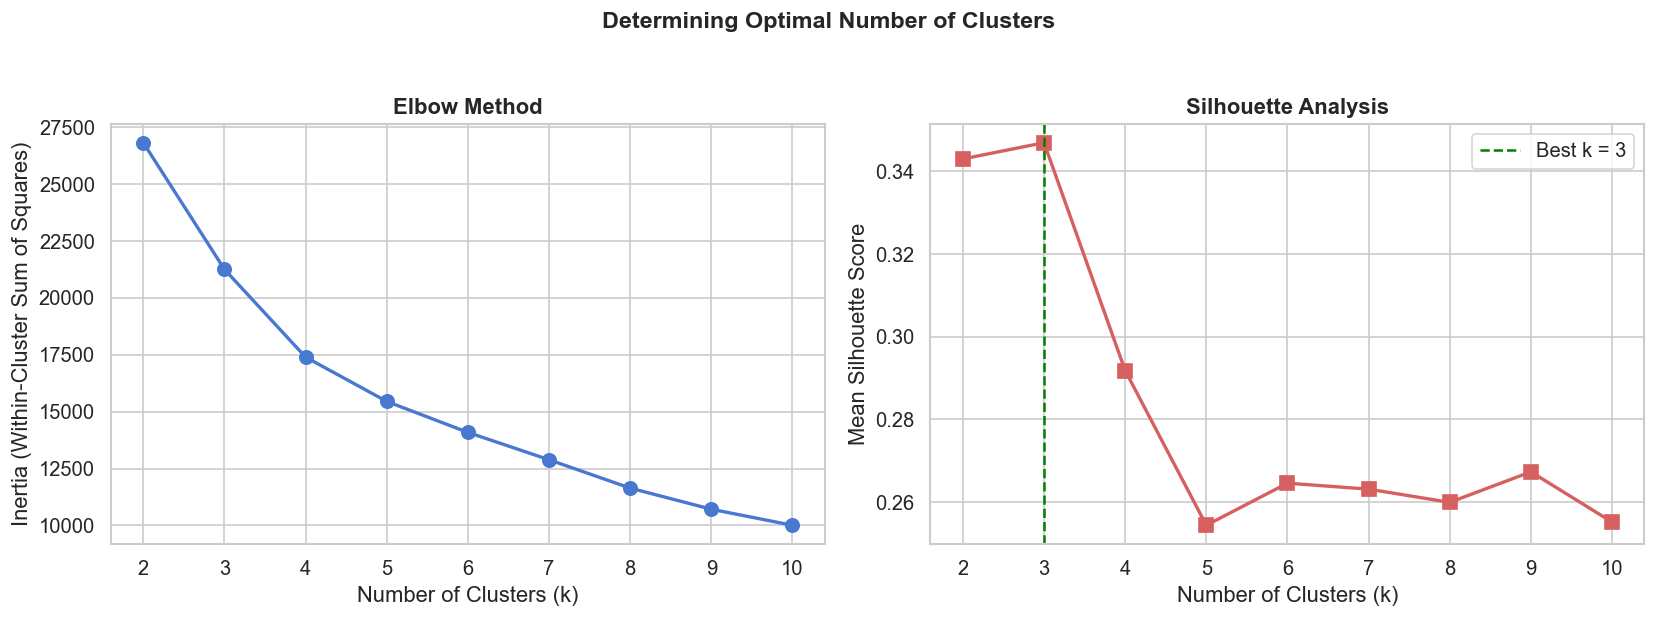

Optimal k by silhouette score: 3

=== Contingency Table: Actual Class vs K-Means Cluster ===
Cluster          0     1   All
Actual Class                  
0             2043    36  2079
1              129  1554  1683
All           2172  1590  3762

=== Cluster Quality Metrics ===
Adjusted Rand Index (ARI):           0.8322  (1 = perfect, 0 = random)
Normalized Mutual Information (NMI):  0.7479  (1 = perfect, 0 = independent)
Cluster Purity:                       0.9561  (1 = pure clusters)
Silhouette Score:                     0.3429


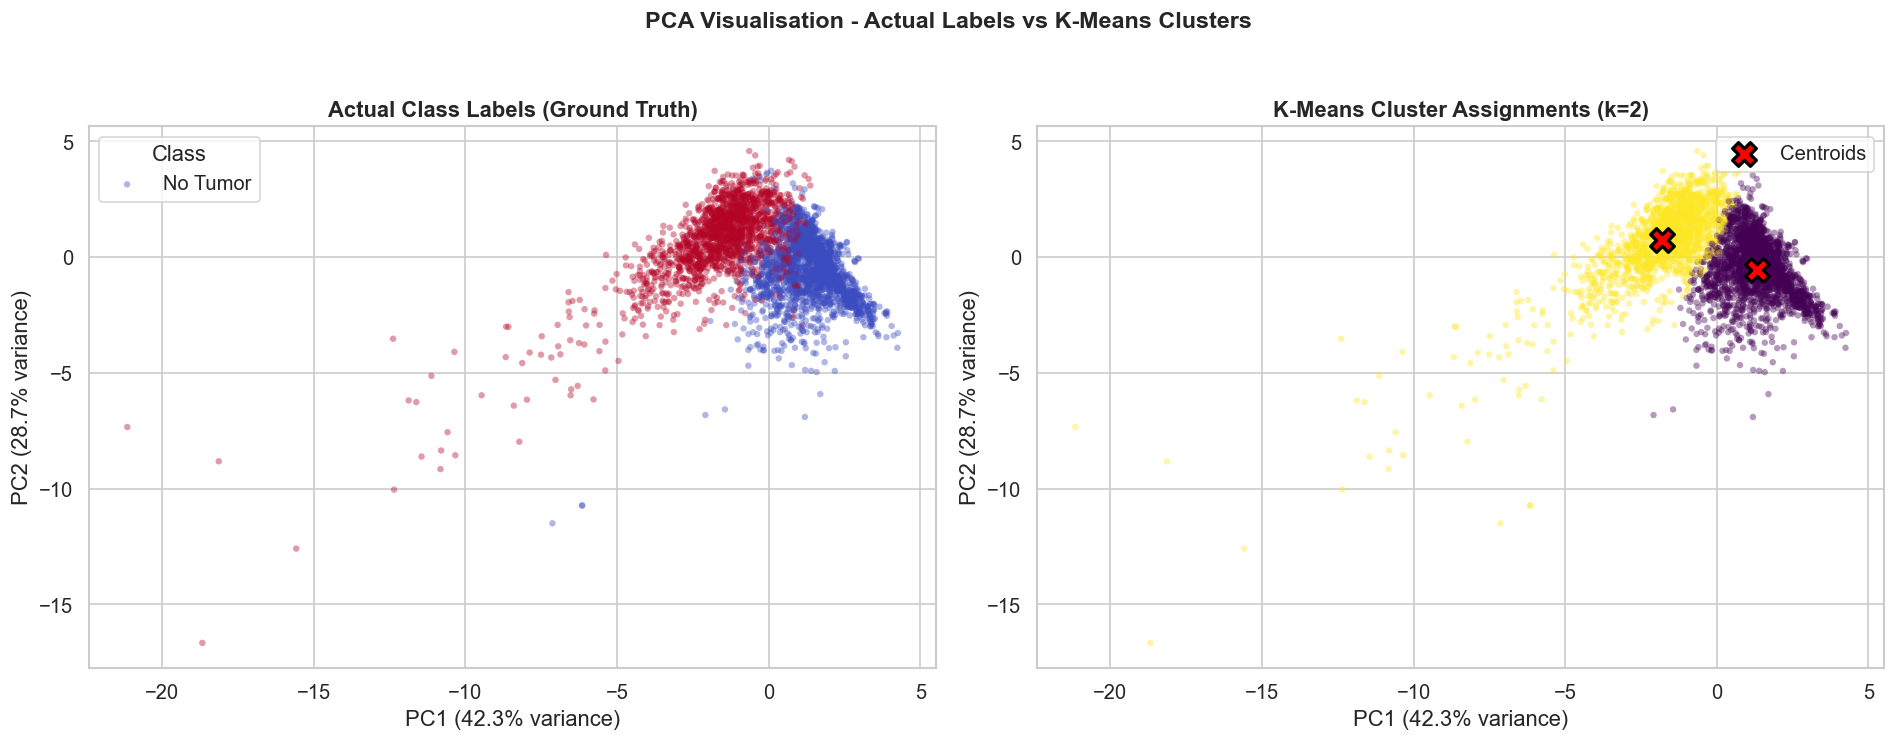

Total PCA variance explained: 71.0%


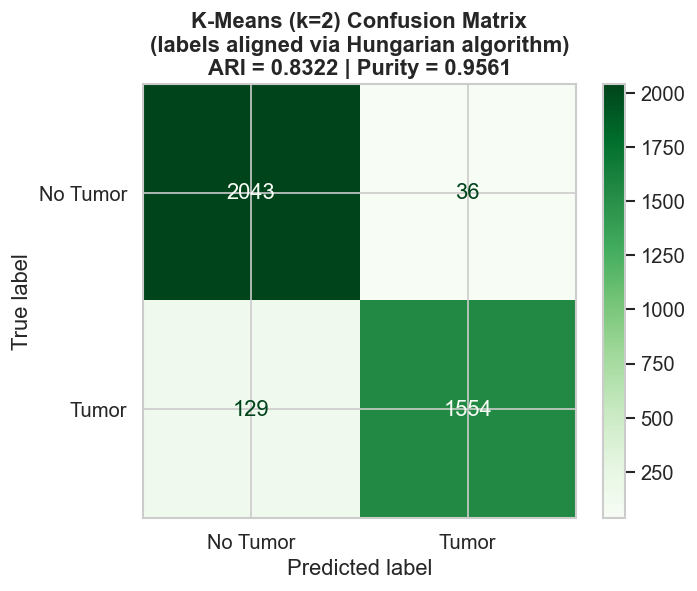


Clustering as Classification (after label alignment):
              precision    recall  f1-score   support

    No Tumor       0.94      0.98      0.96      2079
       Tumor       0.98      0.92      0.95      1683

    accuracy                           0.96      3762
   macro avg       0.96      0.95      0.96      3762
weighted avg       0.96      0.96      0.96      3762



In [37]:
# 8. CLUSTERING ANALYSIS

# Scale features for clustering
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(X_clean)

# --- 8.1 Elbow Method + Silhouette Score ---
k_range = range(2, 11)
inertias = []
silhouette_scores_list = []

print('\nEvaluating k values:')
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, labels)
    silhouette_scores_list.append(sil)
    print(f'  k={k}: Inertia={km.inertia_:.1f}, Silhouette={sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, silhouette_scores_list, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_title('Silhouette Analysis', fontweight='bold')
axes[1].set_xticks(list(k_range))

best_k_silhouette = list(k_range)[np.argmax(silhouette_scores_list)]
axes[1].axvline(x=best_k_silhouette, color='green', linestyle='--', linewidth=1.5,
                label=f'Best k = {best_k_silhouette}')
axes[1].legend()

plt.suptitle('Determining Optimal Number of Clusters', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight')
plt.show()
print(f'Optimal k by silhouette score: {best_k_silhouette}')

# --- 8.2 K-Means with k=2 ---
km_final = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
cluster_labels = km_final.fit_predict(X_cluster)

# Contingency table
contingency = pd.crosstab(
    pd.Series(y.values, name='Actual Class'),
    pd.Series(cluster_labels, name='Cluster'),
    margins=True
)
print('\n=== Contingency Table: Actual Class vs K-Means Cluster ===')
print(contingency)

# Cluster quality metrics
ari = adjusted_rand_score(y, cluster_labels)
nmi = normalized_mutual_info_score(y, cluster_labels)
contingency_no_margin = pd.crosstab(y, cluster_labels)
purity = contingency_no_margin.max(axis=0).sum() / len(y)
sil_final = silhouette_score(X_cluster, cluster_labels)

print(f'\n=== Cluster Quality Metrics ===')
print(f'Adjusted Rand Index (ARI):           {ari:.4f}  (1 = perfect, 0 = random)')
print(f'Normalized Mutual Information (NMI):  {nmi:.4f}  (1 = perfect, 0 = independent)')
print(f'Cluster Purity:                       {purity:.4f}  (1 = pure clusters)')
print(f'Silhouette Score:                     {sil_final:.4f}')

# --- 8.3 PCA Visualisation ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y.values, cmap='coolwarm',
                           alpha=0.4, s=15, edgecolors='none')
axes[0].set_title('Actual Class Labels (Ground Truth)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend(*scatter1.legend_elements(), title='Class', labels=['No Tumor', 'Tumor'])

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis',
                           alpha=0.4, s=15, edgecolors='none')
centres_pca = pca.transform(km_final.cluster_centers_)
axes[1].scatter(centres_pca[:, 0], centres_pca[:, 1], c='red', marker='X',
                s=200, edgecolors='black', linewidth=2, zorder=5, label='Centroids')
axes[1].set_title('K-Means Cluster Assignments (k=2)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend(loc='upper right')

plt.suptitle('PCA Visualisation - Actual Labels vs K-Means Clusters',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('pca_clusters_vs_actual.png', bbox_inches='tight')
plt.show()
print(f'Total PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# --- 8.4 Aligned Confusion Matrix ---
contingency_matrix = pd.crosstab(y, cluster_labels).values
row_ind, col_ind = linear_sum_assignment(-contingency_matrix)
label_mapping = {col_ind[i]: row_ind[i] for i in range(len(col_ind))}
cluster_labels_mapped = np.array([label_mapping[c] for c in cluster_labels])

cm_cluster = confusion_matrix(y, cluster_labels_mapped)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_cluster, display_labels=['No Tumor', 'Tumor']).plot(ax=ax, cmap='Greens')
ax.set_title(f'K-Means (k=2) Confusion Matrix\n(labels aligned via Hungarian algorithm)\n'
             f'ARI = {ari:.4f} | Purity = {purity:.4f}', fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_confusion_matrix.png', bbox_inches='tight')
plt.show()

print('\nClustering as Classification (after label alignment):')
print(classification_report(y, cluster_labels_mapped, target_names=['No Tumor', 'Tumor']))

## 9. Summary & Conclusions

In [36]:
# 9. FINAL SUMMARY

print('\n--- Dataset ---')
print(f'Samples: {len(df)}')
print(f'Original features: {X.shape[1]} (12)')
print(f'Features after removal: {X_clean.shape[1]}')
print(f'Features dropped: {features_to_drop}')
print(f'Justification: Mathematical redundancy (Variance=StdDev^2, ASM=Energy^2) & high correlation')

print('\n--- Classification Results (Test Set) ---')
print(results_df.round(4).to_string())

best_model_name = results_df['F1-Score'].idxmax()
best_f1 = results_df.loc[best_model_name, 'F1-Score']
best_auc = results_df.loc[best_model_name, 'AUC-ROC']
print(f'\nBest model: {best_model_name} (F1={best_f1:.4f}, AUC-ROC={best_auc:.4f})')

print(f'\n--- Top 2 Features (Consensus) ---')
print(f'{consensus_top2}')

print(f'\n--- Clustering (K-Means, k=2) ---')
print(f'Adjusted Rand Index:           {ari:.4f}')
print(f'Normalized Mutual Information:  {nmi:.4f}')
print(f'Cluster Purity:                 {purity:.4f}')

if ari > 0.5:
    print('\n>>> Strong cluster-class alignment: the textural/statistical features')
    print('    naturally separate tumor from non-tumor MRI scans.')
elif ari > 0.2:
    print('\n>>> Moderate cluster-class alignment: features partially capture the')
    print('    tumor/non-tumor distinction, but supervised learning is needed.')
else:
    print('\n>>> Weak cluster-class alignment: the unsupervised structure does not')
    print('    strongly correspond to tumor presence. This highlights the value')
    print('    of supervised learning for this classification task.')

print('\n--- Generated Plots ---')
import glob
plots = sorted(glob.glob('*.png'))
for p in plots:
    print(f'  {p}')


--- Dataset ---
Samples: 3762
Original features: 12 (12)
Features after removal: 10
Features dropped: ['Variance', 'ASM']
Justification: Mathematical redundancy (Variance=StdDev^2, ASM=Energy^2) & high correlation

--- Classification Results (Test Set) ---
                     Accuracy  Precision  Recall (Tumor)  F1-Score  AUC-ROC
Model                                                                      
Logistic Regression    0.9907     0.9911          0.9881    0.9896   0.9993
Random Forest          0.9934     1.0000          0.9852    0.9925   0.9971
XGBoost                0.9907     0.9940          0.9852    0.9896   0.9986

Best model: Random Forest (F1=0.9925, AUC-ROC=0.9971)

--- Top 2 Features (Consensus) ---
['Energy', 'Entropy']

--- Clustering (K-Means, k=2) ---
Adjusted Rand Index:           0.8322
Normalized Mutual Information:  0.7479
Cluster Purity:                 0.9561

>>> Strong cluster-class alignment: the textural/statistical features
    naturally separate tumo